In [1]:
import numpy as np
from numpy.polynomial.hermite import hermgauss
import math
from scipy.special import eval_hermite
from scipy.special import hermite
from matplotlib import pyplot as plt
from scipy.integrate import simpson

In [2]:
def log_normalization_const_squared(nu, n): 
    log_normalization_const_squared = np.log(np.sqrt(2 * nu))
    log_normalization_const_squared -= np.log(np.pow(np.pi, 1/2)) 
    log_normalization_const_squared -= np.log(2) * (2*n)
    log_normalization_const_squared -= math.lgamma(2 * n + 2)
    return log_normalization_const_squared

def HO_energy(n_basis):
    diag = [2*n + 3/2 for n in range(0, n_basis)]
    energy = np.diag(diag)
    return energy

def wavefunction(coefficients,x):
    wavefunction=0
    for k in range(len(coefficients)):
        if x==0:
            wavefunction+=np.exp(log_normalization_const_squared(0.5, k)/2) / np.sqrt(4*np.pi) * coefficients[k]*hermite(2*k+1).deriv()(0)*np.exp(-x*x/2)
        else:
            wavefunction+=np.exp(log_normalization_const_squared(0.5, k)/2) / np.sqrt(4*np.pi) * coefficients[k]*eval_hermite(2*k+1,x)/(x)*np.exp(-x*x/2)
    return wavefunction


def modified_hermite_polynomial(x, eta, d1, d2):
    return eval_hermite(d1, eta * x) * eval_hermite(d2, eta * x)

def potential_energy_entry(coefficients, n, m, nu, N, a):
    M=len(coefficients)
    points, weights = hermgauss(m + n +2*M+ 20)
    gauss_hermite_integral=0
    for i in range(len(points)):
        gauss_hermite_integral += weights[i] /2 * modified_hermite_polynomial(points[i], np.sqrt(0.5), 2*m+1, 2*n+1) * np.pow(wavefunction(coefficients,np.sqrt(0.5)*points[i])/np.exp(-0.25*points[i]*points[i]),2) #wavefunction divided by the exponential part because it is already considered in the exponential outside
    coefficient=(N-1)*a* np.sqrt(2)/2*4*np.pi *np.exp((log_normalization_const_squared(nu, n)+log_normalization_const_squared(nu, m))/2)
    return coefficient*gauss_hermite_integral

def potential_energy(coefficients, nu, N, a):
    M=len(coefficients)
    potential_energy=np.zeros((M,M))
    for n in range(M):
        for m in range(M):
            potential_energy[n,m]=potential_energy_entry(coefficients, n, m, nu, N, a)
    return potential_energy


def hamiltonian(coefficients, old_coefficients, alpha, nu, N, a):
    M=len(coefficients)
    HO=HO_energy(M)
    #print(HO)
    potential=(1-alpha)*potential_energy(coefficients, nu, N, a)+alpha*potential_energy(old_coefficients, nu, N, a)
    #print(potential)
    return HO+potential

def true_energy(coefficients,old_coefficients,N,a,mu):
    #print(coefficients)
    ho_energy=0
    for n in range(len(coefficients)):
        ho_energy+=np.pow(coefficients[n],2)*(2*n+3/2)
    #
    # print(ho_energy)
    x=np.arange(0.01,7,0.001)
    psi=[]
    for coord in x:
        psi.append((wavefunction(old_coefficients,coord)))
    psi=np.array(psi)
    wavefunction_integral=(N-1)*a*np.pow(4*np.pi,2)*simpson(np.pow(psi,4)*x*x,x)
    energy_difference=mu-ho_energy-wavefunction_integral
    true_energy=ho_energy+wavefunction_integral /2
    return true_energy, energy_difference

#true_energy([1,0,0,0],1000,1,0)
def ground_state(old_coefficients, old_old_coefficients, alpha, nu, N, a):
    energies, new_coefficients = np.linalg.eigh(hamiltonian(old_coefficients,old_old_coefficients, alpha, nu, N, a))
    return energies[0], new_coefficients[0]

#first_guess=[1,0,0,0,0,0,0,0,0,0]

#new_state=ground_state(first_guess,np.zeros(len(first_guess)),0.5,0.5,100,0.01)

def plot_state(coefficients,it):
    x=np.arange(0.01,7,0.01)
    y=[]
    for coord in x:
        y.append((wavefunction(coefficients,coord)))
    y=np.array(y)
    #plt.plot(x,y,label=str(it))
    plt.plot(x,y*y*x*x*4*np.pi,label=str(it))    #radial probability density
    plt.legend(loc='upper right')
    #print("Area=",(simpson(y*y*x*x*4*np.pi,x)))
    return 0
#plot_state(first_guess,1)
#plot_state(new_state[1],2)

E at  0  iteration=  1.5
Delta_E at  0  iteration=  0.0
E at  1  iteration=  1.9358329818402953
Delta_E at  1  iteration=  -0.4711999755024727
E at  2  iteration=  1.8934959886662273
Delta_E at  2  iteration=  -0.04878193434772482
E at  3  iteration=  1.779869497546143
Delta_E at  3  iteration=  0.05859894698526569
E at  4  iteration=  1.8044100016430793
Delta_E at  4  iteration=  -0.012694006205659525
E at  5  iteration=  1.8244820586647654
Delta_E at  5  iteration=  -0.01783245381107157
E at  6  iteration=  1.812497052049824
Delta_E at  6  iteration=  0.003780535731114698
E at  7  iteration=  1.8096797167732825
Delta_E at  7  iteration=  0.0005439342337726361
E at  8  iteration=  1.814046980116417
Delta_E at  8  iteration=  -0.00485771737688212
E at  9  iteration=  1.8135475032202002
Delta_E at  9  iteration=  -0.0022071326656377677
E at  10  iteration=  1.8123422924999455
Delta_E at  10  iteration=  -0.0013440041628757227
E at  11  iteration=  1.8128685503008954
Delta_E at  11  iter

(np.float64(2.06609045980624),
 np.float64(1.8128971974345494),
 array([ 9.86526690e-01,  1.57845307e-01, -4.13575262e-02,  1.14569617e-02,
         2.81895480e-03, -3.75313216e-04,  2.02532016e-04, -2.52525152e-04,
        -1.86054587e-04,  1.20099420e-04]))

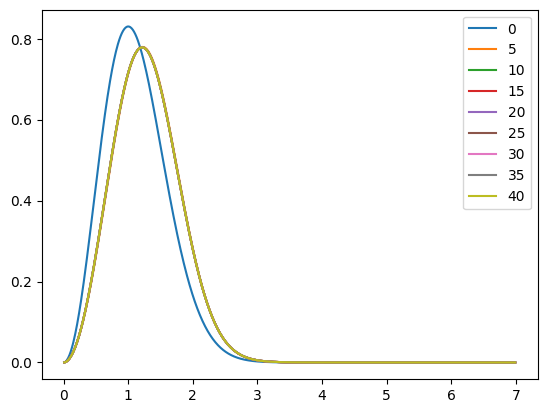

In [10]:
def iterative_GP(first_guess,alpha,nu,N,a,N_iterations,delta_E_stop):
    old_coord=first_guess
    old_old_coord=np.zeros(len(first_guess))
    for i in range(N_iterations):
        new_mu, new_coord=ground_state(old_coord,old_old_coord,alpha,nu,N,a)
        if i%5==0:
            plot_state(new_coord,i)
        #print("Mu at ",(i)," iteration= ",(new_mu))
        E, E_difference =true_energy(new_coord,old_coord,N,a,new_mu)
        print("E at ",(i)," iteration= ",(E))
        print("Delta_E at ",(i)," iteration= ",(E_difference))
        #print("Normalization=",(np.sum(new_coord**2)))
        if abs(E_difference)<delta_E_stop and i>1:
            print("Convergence reached!")
            plot_state(new_coord,i)
            break
        old_old_coord=old_coord
        old_coord=new_coord
    return new_mu, E, new_coord

first_guess=np.zeros(10)
mixing=0.5
iterative_GP(first_guess,mixing,0.5,1e3,1e-3,41,1e-6)
